### Practical 8: Convolutional Neural Networks (CNN)

**Objective**
To understand how CNNs extract spatial features from images and outperform traditional MLPs.

**Dataset**
We use the CIFAR-10 dataset:
- 32x32 RGB images
- 10 classes (airplane, car, dog, etc.)

**Goal**
To compare MLP vs CNN and understand feature extraction.

In [67]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import tensorflow as tf

In [68]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [69]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten
from keras.utils import to_categorical

In [70]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [71]:
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (50000, 32, 32, 3)
Testing Data Shape: (10000, 32, 32, 3)


The dataset contains:
- 50,000 training images
- 10,000 testing images

Each image has dimensions:
32 x 32 pixels with 3 color channels (RGB)

This means each image is represented as a 3D array.

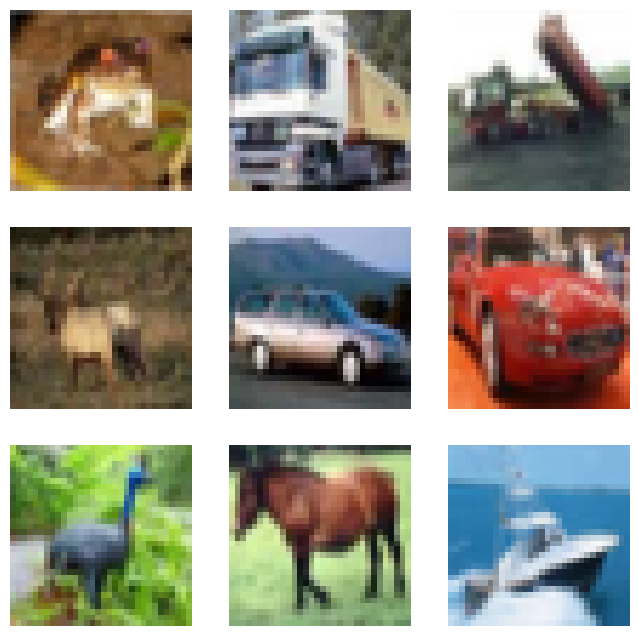

In [72]:
plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i])
    plt.axis('off')

plt.show()

Visualizing CIFAR-10 Images

We display sample images to understand:
- Different object categories
- Image resolution (32x32)
- Color information (RGB)

This helps us understand the input data before applying models.

In [73]:
X_train = X_train / 255.0
X_test = X_test / 255.0

Data Normalization

Pixel values are scaled from [0,255] to [0,1].

This improves:
- Training speed
- Model performance
- Numerical stability

In [74]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

**One-Hot Encoding**

Labels are converted into one-hot vectors.

Example:
Class 3 → [0,0,0,1,0,0,0,0,0,0]

This is required because the output layer has 10 neurons (one per class).

**Task 1: MLP Failure Test (Baseline)**

In this step, we use a simple Dense Neural Network (MLP) to classify images.

The images are flattened into 1D vectors, which removes spatial structure.

This demonstrates why MLPs perform poorly on image data.

In [75]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

**Flattening Images**

Each 32x32x3 image is converted into a 1D vector of size 3072.

This removes spatial relationships between pixels, which is why MLP struggles with image data.

In [76]:
#Importing MLP Lyers

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [77]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

mlp_model = Sequential()

mlp_model.add(Input(shape=(3072,)))

mlp_model.add(Dense(512, activation='relu'))
mlp_model.add(Dense(256, activation='relu'))
mlp_model.add(Dense(10, activation='softmax'))

Architecture:
Input → Dense(512) → Dense(256) → Output(10)

We build a Dense neural network where:
- Input size = 3072 (flattened image)
- Hidden layers = 512 and 256 neurons
- Output layer = 10 neurons (softmax)

This leads to a large number of parameters in the first layer, causing inefficiency.

In [78]:
mlp_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

**Model Compilation**

We use:
- Adam optimizer for efficient learning
- Categorical crossentropy for multi-class classification
- Accuracy as evaluation metric

In [79]:
history_mlp = mlp_model.fit(
    X_train_flat, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.2748 - loss: 2.0463 - val_accuracy: 0.3412 - val_loss: 1.8234
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.3803 - loss: 1.7223 - val_accuracy: 0.4082 - val_loss: 1.6624
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.4189 - loss: 1.6191 - val_accuracy: 0.4283 - val_loss: 1.6136
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.4452 - loss: 1.5519 - val_accuracy: 0.4337 - val_loss: 1.5846
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.4545 - loss: 1.5142 - val_accuracy: 0.4331 - val_loss: 1.6019
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.4727 - loss: 1.4711 - val_accuracy: 0.4586 - val_loss: 1.5298
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.4811 - loss: 1.4480 - val_accuracy: 0.4701 - val_loss: 1.5059
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.4942 - loss: 1.4191 - v

**Training MLP Model**

The model is trained on flattened image data.

Due to lack of spatial understanding, performance is expected to be limited.

In [80]:
loss, accuracy = mlp_model.evaluate(X_test_flat, y_test)
print("MLP Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4747 - loss: 1.4750
MLP Test Accuracy: 0.4772999882698059


MLP Performance

The accuracy is expected to be low compared to CNN.

This demonstrates that MLPs are not suitable for image classification tasks.

In [81]:
mlp_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,121,824 (19.54 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,414,550 (13.03 MB)

Model Analysis

The summary shows a massive number of parameters in the first layer.

This happens because every pixel is connected to every neuron, leading to parameter explosion.

This proves MLP is inefficient for image data.

**Task 2: Building CNN Model**

We now build a Convolutional Neural Network (CNN) that can extract spatial features from images.

Unlike MLP, CNN preserves spatial relationships using convolution and pooling layers.

In [82]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten

**CNN Layers**

- Conv2D extracts features like edges and shapes.
- MaxPooling reduces image size and retains important information.
- Flatten converts feature maps into a vector for classification.

In [83]:
from tensorflow.keras.layers import Input

cnn_model = Sequential()

cnn_model.add(Input(shape=(32,32,3)))

cnn_model.add(Conv2D(32, (3,3), activation='relu'))
cnn_model.add(MaxPooling2D((2,2)))

cnn_model.add(Conv2D(64, (3,3), activation='relu'))
cnn_model.add(MaxPooling2D((2,2)))

cnn_model.add(Flatten())

cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dense(10, activation='softmax'))

CNN Architecture

The CNN consists of:
- Two convolutional layers for feature extraction
- Two max pooling layers for dimensionality reduction
- A flatten layer to convert feature maps into vectors
- Dense layers for classification

This architecture allows the model to learn spatial hierarchies.

In [84]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

CNN Compilation

We use Adam optimizer and categorical crossentropy loss for multi-class classification.

In [85]:
history_cnn = cnn_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 37ms/step - accuracy: 0.3658 - loss: 1.7420 - val_accuracy: 0.5553 - val_loss: 1.2611
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - accuracy: 0.5686 - loss: 1.2085 - val_accuracy: 0.6246 - val_loss: 1.0846
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.6349 - loss: 1.0475 - val_accuracy: 0.6350 - val_loss: 1.0479
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - accuracy: 0.6713 - loss: 0.9454 - val_accuracy: 0.6508 - val_loss: 1.0150
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - accuracy: 0.6922 - loss: 0.8878 - val_accuracy: 0.6614 - val_loss: 0.9970
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 38ms/step - accuracy: 0.7189 - loss: 0.8092 - val_accuracy: 0.6721 - val_loss: 0.9671
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.7418 - loss: 0.7411 - val_accuracy: 0.6863 - val_loss: 0.9209
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - accuracy: 0.7644 - loss: 0.6807 - 

Training CNN

The CNN is trained on image data, allowing it to learn spatial patterns such as edges and textures.

In [86]:
loss, accuracy = cnn_model.evaluate(X_test, y_test)
print("CNN Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6960 - loss: 0.9537
CNN Test Accuracy: 0.6894000172615051


CNN Performance

The CNN achieves higher accuracy than the MLP, proving that CNNs are better suited for image data due to spatial feature extraction.

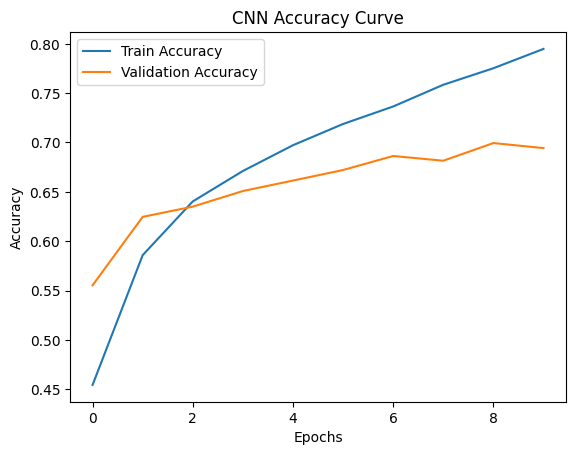

In [87]:
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')

plt.title("CNN Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Accuracy Curve

The accuracy curve shows how the CNN improves over epochs.

Training accuracy increases, demonstrating learning of image features.

In [88]:
cnn_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 947,168 (3.61 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 631,446 (2.41 MB)

**CNN Model Summary**

The model summary shows the number of parameters in each layer.

Compared to MLP, CNN has significantly fewer parameters due to weight sharing in convolutional layers.

In [89]:
# Manual parameter calculation for first Conv2D layer

kernel_width = 3
kernel_height = 3
input_depth = 3   # RGB channels
filters = 32

params = (kernel_width * kernel_height * input_depth + 1) * filters

print("Manual Parameter Calculation:", params)

Manual Parameter Calculation: 896


This shows that each filter is applied across all RGB channels, and the same filter is reused across the entire image (parameter sharing).

**Task 4: Feature Map Visualization**

In this step, we visualize the feature maps generated by the first convolutional layer.

This helps us understand what patterns the CNN has learned from the image.

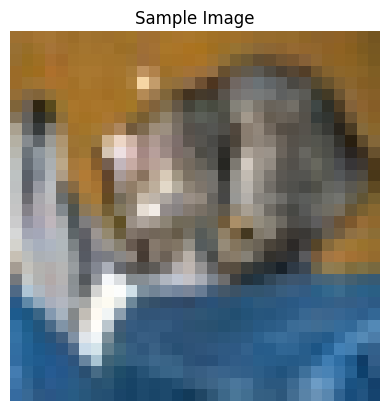

In [90]:
sample_image = X_test[0]
plt.imshow(sample_image)
plt.title("Sample Image")
plt.axis('off')
plt.show()

In [93]:
from tensorflow.keras.models import Model

feature_extractor = Model(
    inputs=cnn_model.inputs,
    outputs=cnn_model.layers[0].output
)

Feature Extractor Model

We create a model that outputs the feature maps from the first convolutional layer.

This allows us to visualize what features are detected.

In [94]:
sample_image = np.expand_dims(sample_image, axis=0)

feature_maps = feature_extractor.predict(sample_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


Generating Feature Maps

The image is passed through the CNN to extract feature maps from the first convolutional layer.

These maps represent detected patterns.

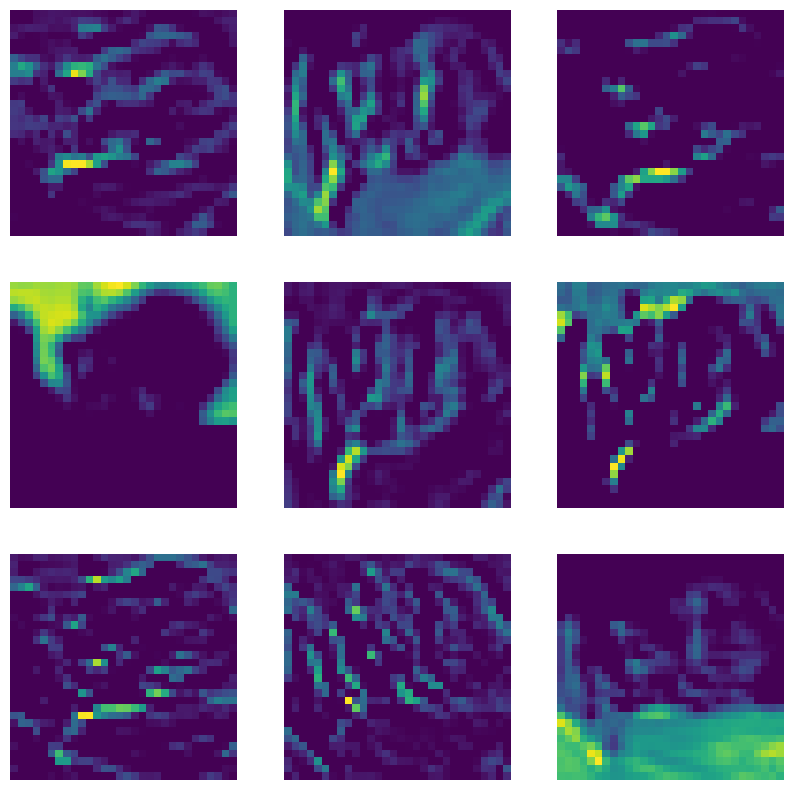

In [95]:
plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(feature_maps[0, :, :, i], cmap='viridis')
    plt.axis('off')

plt.show()

**Analysis of Feature Maps**

The feature maps show that different filters focus on different aspects of the image.

Some filters act as edge detectors, highlighting boundaries of objects such as the edges of a car.

Other filters capture textures or specific shapes like wheels.

This proves that CNN learns hierarchical representations of images, starting from simple patterns to complex features.